# 01 — Market Data Setup

Pull every market input the FCN pricer needs from public sources, and sanity-check it before we feed it into the simulator.

Inputs covered:

1. **Spots** — latest yfinance daily close per name.
2. **Volatilities** — ATM implied vol from the 1Y options chain, with realised-vol and hardcoded fallbacks.
3. **Dividend yields** — `dividendRate / regularMarketPrice` from yfinance fundamentals.
4. **Risk-free rate** — interpolated 1Y point from `^IRX` and `^FVX` Treasury series.
5. **Correlation matrix** — Pearson on daily log-returns.

Disclaimer: the FCN structure that uses this data is hypothetical (textbook parameters). Nothing here resembles a live issuance.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make `src` importable regardless of where Jupyter was launched.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.market_data import load_market_data, realised_stats

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True})

## 1. Load the snapshot

One call hits yfinance for everything: 5Y of daily history, dividend fundamentals, Treasury yields. The loaders log fallbacks if any data source returns garbage, so re-runs outside US trading hours are safe.

We pin `as_of=2025-10-17` so the snapshot matches the dashboard and notebook 07's canonical date — no drift on re-runs. yfinance does not serve historical options chains, so this loader falls back to **5Y realised** vol for any historical `as_of`. The dashboard's hardcoded vols in `dashboard/state.py` (35.02% / 43.97% / 47.13%) are these exact realised numbers — `state.py` labels them as implied in a comment, but they were copied from notebook 07's realised-vol snapshot. So the printout below matches the deployed pricer's inputs one-for-one.

In [2]:
md = load_market_data(
    tickers=("AMZN", "META", "MU"),
    lookback_years=5,
    target_T=1.0,
    as_of=date(2025, 10, 17),   # match the dashboard / nb 07 snapshot
)
print(md.summary())

MarketData snapshot as of 2026-05-20T16:30:07.704042+00:00
Tickers      : ['AMZN', 'META', 'MU']
Spots        : {'AMZN': np.float64(213.04), 'META': np.float64(715.723), 'MU': np.float64(202.2133)}
Vols (ann.)  : {'AMZN': np.float64(0.3502), 'META': np.float64(0.4397), 'MU': np.float64(0.4713)}
Div yields   : {'AMZN': np.float64(0.0), 'META': np.float64(0.0029), 'MU': np.float64(0.00227)}
Risk-free 1Y : 0.03794
Correlation matrix:
        AMZN    META      MU
AMZN  1.0000  0.6139  0.4422
META  0.6139  1.0000  0.4176
MU    0.4422  0.4176  1.0000
Sources:
  as_of: 2025-10-17
  spots: yfinance daily closes (last bar on or before 2025-10-17)
  history: yfinance 5Y daily closes ending 2025-10-17
  realised_vols: log-return std × √252
  implied_vols: AMZN: realised 5Y vol (0.3502) @ 2025-10-17; META: realised 5Y vol (0.4397) @ 2025-10-17; MU: realised 5Y vol (0.4713) @ 2025-10-17
  dividends: AMZN: hardcoded fallback (0.0000); META: trailing 12M dividends / spot @ 2025-10-17 (0.0029); MU: tr

## 2. Realised vs implied vols

Implied is what we feed into the risk-neutral simulator (it's what the market is actually paying for variance). Realised is the empirical 5Y number — useful as a sanity check and as a fallback when the chain is illiquid.

In [3]:
realised_vols, _ = realised_stats(md.history)
vol_df = pd.DataFrame(
    {"Implied (used)": md.vols, "Realised 5Y": realised_vols},
    index=list(md.tickers),
)
vol_df.round(4)

,Implied (used),Realised 5Y
AMZN,0.3502,0.3502
META,0.4397,0.4397
MU,0.4713,0.4713


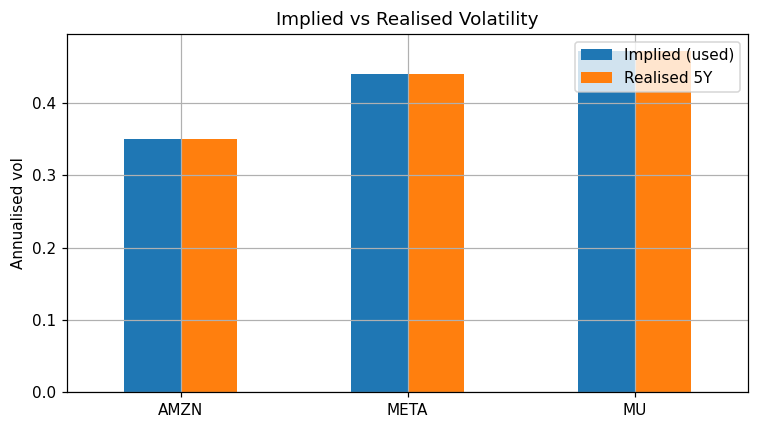

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
vol_df.plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e"])
ax.set_title("Implied vs Realised Volatility")
ax.set_ylabel("Annualised vol")
ax.set_xlabel("")
ax.legend(loc="upper right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Correlation structure

Pearson on daily log-returns over the full 5Y window. The basket is large-cap US tech (AMZN, META, MU), so we expect moderate-to-tight co-movement — typically in the 0.4–0.7 range, with the MU pairings looser than the AMZN/META pairing. The level of correlation is the single biggest driver of worst-of FCN value (long correlation), so this is the input the desk would re-mark most carefully.

In [5]:
corr_df = pd.DataFrame(md.corr, index=list(md.tickers), columns=list(md.tickers))
corr_df.round(4)

,AMZN,META,MU
AMZN,1.0000,0.6139,0.4422
META,0.6139,1.0000,0.4176
MU,0.4422,0.4176,1.0000


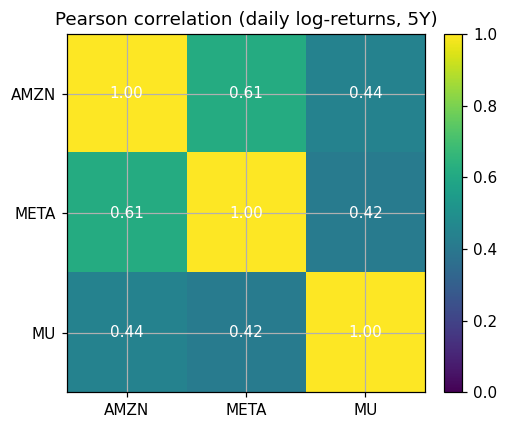

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(md.corr, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(md.tickers)))
ax.set_yticks(range(len(md.tickers)))
ax.set_xticklabels(md.tickers)
ax.set_yticklabels(md.tickers)
for i in range(len(md.tickers)):
    for j in range(len(md.tickers)):
        ax.text(j, i, f"{md.corr[i, j]:.2f}", ha="center", va="center", color="white")
ax.set_title("Pearson correlation (daily log-returns, 5Y)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 4. Spot history

Quick visual on the 5Y closes the realised stats are computed from. Rebased to 100 to make the relative paths comparable — useful when forming priors on the worst-performer dynamics.

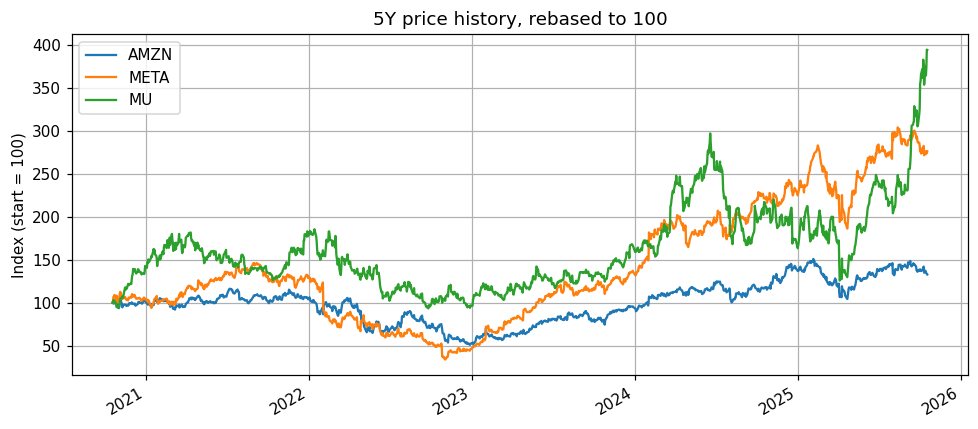

In [7]:
rebased = md.history.div(md.history.iloc[0]).mul(100.0)
fig, ax = plt.subplots(figsize=(9, 4))
rebased.plot(ax=ax)
ax.set_title("5Y price history, rebased to 100")
ax.set_ylabel("Index (start = 100)")
ax.set_xlabel("")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 5. Sanity checks before Phase 2

Things to confirm visually:

- All three vols sit in a plausible range for liquid large-cap US tech (~0.30 – 0.60).
- Dividend yields are tiny (AMZN = 0%, META <0.5%, MU <0.3%).
- Risk-free rate matches the front of the Treasury curve.
- Correlation matrix is positive semi-definite (it should be — eigenvalues all ≥ 0).
- Spot history doesn't have wild gaps.


In [8]:
from src.utils import is_psd

checks = {
    "vols sane (0.10 – 1.50)": bool(((md.vols >= 0.10) & (md.vols <= 1.50)).all()),
    "divs sane (0 – 10%)": bool(((md.divs >= 0) & (md.divs <= 0.10)).all()),
    "rate sane (0 – 10%)": bool(0 <= md.rate <= 0.10),
    "corr is PSD": is_psd(md.corr),
    "corr diag = 1": bool(np.allclose(np.diag(md.corr), 1.0)),
    "history len > 1000 days": len(md.history) > 1000,
}
pd.Series(checks, name="passed")

vols sane (0.10 – 1.50)    True
divs sane (0 – 10%)        True
rate sane (0 – 10%)        True
corr is PSD                True
corr diag = 1              True
history len > 1000 days    True
Name: passed, dtype: bool

## Checkpoint 1 — outputs to review

- A correlation matrix.
- An annualised vol per ticker (implied + realised).
- All market inputs printed with their source.

If those three are good, we move on to **Phase 2: GBM simulation engine**.